# STAGATE zero-value imputation for one selected Deep-STARmap cell type

This notebook selects one cell type, runs STAGATE 3D denoising/imputation, and exports the reconstructed expression matrix plus 3D coordinates for R.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
from scipy import sparse, io
from sklearn.neighbors import NearestNeighbors

import scanpy as sc
import anndata as ad
import STAGATE

## 1. Settings
Change `target_celltype`, coordinate column names, and output directory if needed.

In [3]:
data_dir = Path(r"D:\MERFISH\brain\Deep_STARMAP")

expr_file = data_dir / "Brain_Deep_STARmap_expression_matrix.csv"
spatial_file = data_dir / "Brain_Deep_STARmap_spatial.csv"

target_celltype = "Peptidergic neurons"
celltype_col = "FUSEmap_main_level"

x_col = "x"
y_col = "y"
z_col = "z"

out_dir = data_dir / "STAGATE_imputation_output" / target_celltype.replace(" ", "_")
out_dir.mkdir(parents=True, exist_ok=True)

prefix = target_celltype.replace(" ", "_")

ERROR! Session/line number was not unique in database. History logging moved to new session 146


## 2. Read CSV files and subset one cell type

In [4]:
def maybe_set_first_col_as_index(df):
    first = str(df.columns[0]).lower()
    if first.startswith("unnamed") or first in {"cell", "cell_id", "cellid", "barcode", "spot", "spot_id", "id"}:
        df = df.set_index(df.columns[0])
    return df

expr = pd.read_csv(expr_file)
expr = maybe_set_first_col_as_index(expr)
expr = expr.apply(pd.to_numeric, errors="coerce")
expr = expr.drop(columns=expr.columns[expr.isna().all()])

spatial = pd.read_csv(spatial_file)
spatial = maybe_set_first_col_as_index(spatial)

assert expr.shape[0] == spatial.shape[0], "expr and spatial must have the same number of rows."

df = spatial[spatial[celltype_col].astype(str) == target_celltype].copy()
expr_sub = expr.loc[df.index].copy()

print("Selected cells:", expr_sub.shape[0])
print("Genes:", expr_sub.shape[1])
print(df[[x_col, y_col, z_col, celltype_col]].head())

Selected cells: 9212
Genes: 1017
         x        y     z   FUSEmap_main_level
192  747.0  10927.0  10.0  Peptidergic neurons
338  632.0  10459.0  70.0  Peptidergic neurons
560  675.0  11971.0  12.0  Peptidergic neurons
617  701.0  11706.0  23.0  Peptidergic neurons
690  938.0  11297.0  32.0  Peptidergic neurons


## 3. Build AnnData and normalize/log1p
For this 1017-gene panel, I recommend using all genes rather than HVG selection.

In [5]:
X = sparse.csr_matrix(expr_sub.to_numpy(dtype=np.float32))
adata = ad.AnnData(X=X)
adata.obs_names = expr_sub.index.astype(str)
adata.var_names = expr_sub.columns.astype(str)
adata.var_names_make_unique()

adata.obs = df.copy()
adata.obs.index = adata.obs_names

adata.obs["X"] = pd.to_numeric(adata.obs[x_col], errors="coerce").astype(float)
adata.obs["Y"] = pd.to_numeric(adata.obs[y_col], errors="coerce").astype(float)
adata.obs["Z"] = pd.to_numeric(adata.obs[z_col], errors="coerce").astype(float)
adata.obs["Section_id"] = adata.obs[z_col].astype(str).values

adata.obsm["spatial"] = adata.obs[["X", "Y"]].to_numpy(dtype=np.float32)
adata.obsm["spatial_3d"] = adata.obs[["X", "Y", "Z"]].to_numpy(dtype=np.float32)

adata.layers["counts"] = adata.X.copy()

sc.pp.filter_cells(adata, min_counts=1)
sc.pp.filter_genes(adata, min_cells=1)

adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

zero_ratio = 1 - adata.layers["counts"].nnz / (adata.n_obs * adata.n_vars)
print(adata)
print("Raw count zero ratio after filtering:", zero_ratio)

AnnData object with n_obs × n_vars = 9212 × 1017
    obs: 'x', 'y', 'z', 'Harmony_labels', 'FUSEmap_main_level', 'FUSEmap_sub_level', 'X', 'Y', 'Z', 'Section_id', 'n_counts'
    var: 'n_cells'
    uns: 'log1p'
    obsm: 'spatial', 'spatial_3d'
    layers: 'counts'
Raw count zero ratio after filtering: 0.9530683546876354


C:\Users\Lenovo\.conda\envs\STAGATE_py3.6_tf_scanpy\lib\site-packages\anndata\_core\anndata.py:801: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [192, 338, 560, 617, 690]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)
C:\Users\Lenovo\.conda\envs\STAGATE_py3.6_tf_scanpy\lib\site-packages\anndata\_core\anndata.py:120: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


## 4. Estimate radius cutoff and build 3D STAGATE graph
If the resulting graph has too few/many neighbors, manually adjust `rad_cutoff_2D` and `rad_cutoff_Zaxis`.

Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.


rad_cutoff_2D: 1385.9841021946463
rad_cutoff_Zaxis: 1385.9841021946463
section_order: ['2.0', '3.0', '4.0', '5.0', '6.0', '7.0', '8.0', '9.0', '10.0', '11.0', '12.0', '13.0', '14.0', '15.0', '16.0', '17.0', '18.0', '19.0', '20.0', '21.0', '22.0', '23.0', '24.0', '25.0', '26.0', '27.0', '28.0', '29.0', '30.0', '31.0', '32.0', '33.0', '34.0', '35.0', '36.0', '37.0', '38.0', '39.0', '40.0', '41.0', '42.0', '43.0', '44.0', '45.0', '46.0', '47.0', '48.0', '49.0', '50.0', '51.0', '52.0', '53.0', '54.0', '55.0', '56.0', '57.0', '58.0', '59.0', '60.0', '61.0', '62.0', '63.0', '64.0', '65.0', '66.0', '67.0', '68.0', '69.0', '70.0', '71.0', '72.0', '73.0', '74.0', '75.0', '76.0', '77.0', '78.0', '79.0', '80.0', '81.0', '82.0', '83.0', '84.0', '85.0', '86.0', '87.0', '88.0', '89.0', '90.0', '91.0', '92.0', '93.0', '94.0', '95.0', '96.0', '97.0', '98.0', '99.0', '100.0', '101.0', '102.0', '103.0', '104.0', '105.0', '106.0', '107.0', '108.0', '109.0', '110.0', '111.0', '112.0', '113.0', '114.0', '1

Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.


This graph contains 384 edges, 37 cells.
10.3784 neighbors per cell on average.
------Calculating 2D SNN of section  105.0
This graph contains 536 edges, 45 cells.
11.9111 neighbors per cell on average.
------Calculating 2D SNN of section  106.0
This graph contains 802 edges, 50 cells.
16.0400 neighbors per cell on average.
------Calculating 2D SNN of section  107.0
This graph contains 540 edges, 48 cells.
11.2500 neighbors per cell on average.
------Calculating 2D SNN of section  108.0
This graph contains 618 edges, 50 cells.
12.3600 neighbors per cell on average.
------Calculating 2D SNN of section  109.0
This graph contains 302 edges, 39 cells.
7.7436 neighbors per cell on average.
------Calculating 2D SNN of section  11.0
This graph contains 1438 edges, 86 cells.
16.7209 neighbors per cell on average.


Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.


...

------Calculating SNN between adjacent section 200.0 and 201.0.
This graph contains 1848 edges, 100 cells.
18.4800 neighbors per cell on average.
------Calculating SNN between adjacent section 201.0 and 202.0.
This graph contains 2200 edges, 107 cells.
20.5607 neighbors per cell on average.


Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.


------Calculating SNN between adjacent section 202.0 and 203.0.
This graph contains 1508 edges, 97 cells.
15.5464 neighbors per cell on average.
------Calculating SNN between adjacent section 203.0 and 204.0.
This graph contains 1490 edges, 98 cells.
15.2041 neighbors per cell on average.


Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.
Trying to set attribute `._uns` of view, copying.


------Calculating SNN between adjacent section 204.0 and 205.0.
This graph contains 1204 edges, 90 cells.
13.3778 neighbors per cell on average.
------Calculating SNN between adjacent section 205.0 and 206.0.
This graph contains 580 edges, 62 cells.
9.3548 neighbors per cell on average.
------Calculating SNN between adjacent section 206.0 and 207.0.
This graph contains 110 edges, 28 cells.
3.9286 neighbors per cell on average.
3D SNN contains 313214 edges, 9212 cells.
34.0007 neighbors per cell on average.


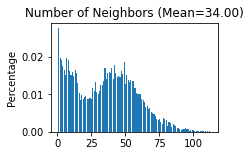

In [6]:
def numeric_sort(values):
    def key_fun(x):
        try:
            return float(x)
        except Exception:
            return str(x)
    return sorted(list(values), key=key_fun)

def estimate_radius_2d(adata, k=6, factor=1.5):
    vals = []
    for sec in numeric_sort(adata.obs["Section_id"].unique()):
        idx = np.where(adata.obs["Section_id"].astype(str).values == str(sec))[0]
        if len(idx) <= k:
            continue
        xy = adata.obsm["spatial"][idx]
        nbrs = NearestNeighbors(n_neighbors=k + 1).fit(xy)
        dist, _ = nbrs.kneighbors(xy)
        vals.append(np.median(dist[:, k]))
    return float(np.median(vals) * factor)

rad_cutoff_2D = estimate_radius_2d(adata, k=6, factor=1.5)
rad_cutoff_Zaxis = rad_cutoff_2D

print("rad_cutoff_2D:", rad_cutoff_2D)
print("rad_cutoff_Zaxis:", rad_cutoff_Zaxis)

section_order = numeric_sort(adata.obs["Section_id"].unique())
print("section_order:", section_order)

STAGATE.Cal_Spatial_Net_3D(
    adata,
    rad_cutoff_2D=rad_cutoff_2D,
    rad_cutoff_Zaxis=rad_cutoff_Zaxis,
    key_section="Section_id",
    section_order=section_order,
    verbose=False,
)
STAGATE.Stats_Spatial_Net(adata)

## 5. Train STAGATE and save reconstructed expression
The official argument name is misspelled as `save_reconstrction=True`.

In [7]:
adata = STAGATE.train_STAGATE(
    adata,
    alpha=0,
    save_reconstrction=True,
)

print(adata)
print("layers:", adata.layers.keys())
print("STAGATE_ReX shape:", adata.layers["STAGATE_ReX"].shape)

Size of Input:  (9212, 1017)
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [13:28<00:00,  1.62s/it]


AnnData object with n_obs × n_vars = 9212 × 1017
    obs: 'x', 'y', 'z', 'Harmony_labels', 'FUSEmap_main_level', 'FUSEmap_sub_level', 'X', 'Y', 'Z', 'Section_id', 'n_counts'
    var: 'n_cells'
    uns: 'log1p', 'Spatial_Net_2D', 'Spatial_Net_Zaxis', 'Spatial_Net'
    obsm: 'spatial', 'spatial_3d', 'STAGATE'
    layers: 'counts', 'STAGATE_ReX'
layers: KeysView(Layers with keys: counts, STAGATE_ReX)
STAGATE_ReX shape: (9212, 1017)


## 6. Export imputed matrix and coordinates for R

In [8]:
Y_imp = adata.layers["STAGATE_ReX"]
if sparse.issparse(Y_imp):
    Y_imp_mat = Y_imp.tocsr()
    Y_imp_dense = Y_imp.toarray().astype(np.float32)
else:
    Y_imp_dense = np.asarray(Y_imp, dtype=np.float32)
    Y_imp_mat = sparse.csr_matrix(Y_imp_dense)

io.mmwrite(out_dir / f"{prefix}_Y_STAGATE_ReX.mtx", Y_imp_mat)

pd.Series(adata.obs_names).to_csv(out_dir / f"{prefix}_spot_ids.tsv", sep="\t", index=False, header=False)
pd.Series(adata.var_names).to_csv(out_dir / f"{prefix}_gene_ids.tsv", sep="\t", index=False, header=False)

S = pd.DataFrame(adata.obsm["spatial_3d"], index=adata.obs_names, columns=["x", "y", "z"])
S.to_csv(out_dir / f"{prefix}_S_3d_coordinates.csv")

adata.obs.to_csv(out_dir / f"{prefix}_obs_metadata.csv")
adata.write_h5ad(out_dir / f"{prefix}_STAGATE.h5ad")

# Convenient but potentially larger file
pd.DataFrame(Y_imp_dense, index=adata.obs_names, columns=adata.var_names).to_csv(
    out_dir / f"{prefix}_Y_STAGATE_ReX.csv.gz",
    compression="gzip"
)

print("Output directory:", out_dir)
print("Y:", Y_imp_mat.shape)
print("S:", S.shape)

... storing 'Harmony_labels' as categorical
... storing 'FUSEmap_main_level' as categorical
... storing 'FUSEmap_sub_level' as categorical
... storing 'Section_id' as categorical


Output directory: D:\MERFISH\brain\Deep_STARMAP\STAGATE_imputation_output\Peptidergic_neurons
Y: (9212, 1017)
S: (9212, 3)


## 7. Optional quick SVG ranking by Moran's I
This is only for sanity-check ranking. Use your formal R/Bayesian model for final SVG detection.

In [9]:
from sklearn.neighbors import NearestNeighbors

Y = Y_imp_dense.astype(np.float64)
coords = adata.obsm["spatial_3d"].astype(float).copy()

# Scale z section IDs to a comparable xy-neighbor distance.
xy = coords[:, :2]
nn = NearestNeighbors(n_neighbors=min(7, adata.n_obs)).fit(xy)
dist, _ = nn.kneighbors(xy)
z_scale = float(np.median(dist[:, -1]))
coords[:, 2] *= z_scale

k = 20
n = adata.n_obs
k_eff = min(k + 1, n)

nbrs = NearestNeighbors(n_neighbors=k_eff).fit(coords)
dist, idx = nbrs.kneighbors(coords)

rows = np.repeat(np.arange(n), k_eff - 1)
cols = idx[:, 1:].reshape(-1)
vals = np.ones_like(rows, dtype=float) / (k_eff - 1)

W = sparse.csr_matrix((vals, (rows, cols)), shape=(n, n))

Z = Y - Y.mean(axis=0, keepdims=True)
WZ = W @ Z
moran_i = np.sum(Z * WZ, axis=0) / (np.sum(Z * Z, axis=0) + 1e-12)

counts = adata.layers["counts"]
zero_ratio_raw = 1 - np.asarray((counts > 0).mean(axis=0)).ravel()

svg_rank = pd.DataFrame({
    "gene": adata.var_names,
    "moran_I_STAGATE_ReX": moran_i,
    "zero_ratio_raw_count": zero_ratio_raw,
}).sort_values("moran_I_STAGATE_ReX", ascending=False)

svg_rank.to_csv(out_dir / f"{prefix}_quick_moran_svg_ranking.csv", index=False)
svg_rank.head(20)

,gene,moran_I_STAGATE_ReX,zero_ratio_raw_count
535,MEIS2,0.936029,0.894594
455,ITIH3,0.921854,0.685410
99,CARTPT,0.905347,0.798089
750,PTK2B,0.904784,0.936062
205,CRYM,0.902040,0.970473
219,CYP26B1,0.892969,0.983500
181,COL6A1,0.891484,0.986865
721,PPP1R1B,0.889300,0.888949
347,GNG8,0.885340,0.976552
144,CHRM1,0.885149,0.963092


## R reading example

In [ ]:
# In R:
# library(Matrix)
# out_dir <- "D:/MERFISH/brain/Deep_STARMAP/STAGATE_imputation_output/Peptidergic_neurons"
# prefix <- "Peptidergic_neurons"
# Y <- readMM(file.path(out_dir, paste0(prefix, "_Y_STAGATE_ReX.mtx")))
# spot_ids <- readLines(file.path(out_dir, paste0(prefix, "_spot_ids.tsv")))
# gene_ids <- readLines(file.path(out_dir, paste0(prefix, "_gene_ids.tsv")))
# rownames(Y) <- spot_ids
# colnames(Y) <- gene_ids
# S <- read.csv(file.path(out_dir, paste0(prefix, "_S_3d_coordinates.csv")),
#               row.names = 1, check.names = FALSE)
# dim(Y)
# dim(S)
# all(rownames(Y) == rownames(S))